# Part V: Simualation

## Basis settings

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.options.display.max_rows = 50
pd.options.display.max_columns = None

In [3]:
DATA_DIR = "../data/processed"

## Load data

In [4]:
forecast_df = pd.read_csv(os.path.join(DATA_DIR, 'forecast.csv'), parse_dates = ['date'])
inventory_df = pd.read_csv(os.path.join(DATA_DIR, 'inventory_processed.csv'), parse_dates = ['date'])
sku_class_df = pd.read_csv(os.path.join(DATA_DIR, 'sku_class.csv'))

## Inventory policy calculation

### New params

In [5]:
forecast_df['squared_error'] = (forecast_df['forecast'] - forecast_df['demand'])**2

forecast_agg = forecast_df.groupby('sku_id').agg(
    rmse         = ('squared_error', lambda x: np.sqrt(x.mean())),
    avg_forecast = ('forecast', 'mean')
).reset_index()

inventory_agg = inventory_df.groupby('sku_id').agg(
    lead_time = ('lead_time', 'mean'),
    unit_cost = ('unit_cost', 'mean'),
    unit_price = ('unit_price', 'mean'),
    order_quantity = ('order_quantity', 'mean'),
).reset_index()

policy_sku = (forecast_agg
    .merge(inventory_agg, on='sku_id')
    .merge(sku_class_df, on='sku_id')
)

In [6]:
from scipy.stats import norm

mapping_sl = {'AX': 99, 'AY': 97, 'CX': 85, 'BZ': 85, 'CZ': 75}

policy_sku['target_service_level'] = policy_sku['class'].map(mapping_sl)
policy_sku['z_score'] = norm.ppf(policy_sku['target_service_level'] / 100)

policy_sku['new_safety_stock'] = policy_sku['z_score'] * policy_sku['rmse'] * (policy_sku['lead_time'] ** 0.5)
policy_sku['new_rop'] = policy_sku['avg_forecast'] * policy_sku['lead_time'] + policy_sku['new_safety_stock']

### Metric old policy

In [7]:
ordering_cost = 50
holding_rate  = 0.25
days = inventory_df['date'].nunique()

target_skus = policy_sku[policy_sku['class'].isin(['AX', 'AY', 'CX', 'BZ', 'CZ'])]['sku_id']

old = inventory_df[inventory_df['sku_id'].isin(target_skus)].merge(policy_sku[['sku_id', 'class']], on='sku_id').copy()

old['lost_sales']   = (old['demand'] - old['sales_quantity']).clip(lower=0)
old['order_placed'] = (old['order_received'] > 0).astype(int)
old['is_stockout'] = (old['demand'] > old['sales_quantity']).astype(int)

old_policy = old.groupby(['sku_id', 'class']).agg(
    total_demand = ('demand', 'sum'),
    total_sales = ('sales_quantity', 'sum'),
    avg_inventory = ('inventory_level', 'mean'),
    total_lost = ('lost_sales', 'sum'),
    num_orders = ('order_placed', 'sum'),
    unit_cost = ('unit_cost', 'mean'),
    unit_price = ('unit_price', 'mean')
).reset_index()

old_policy['fill_rate'] = old_policy['total_sales'] / old_policy['total_demand']
old_policy['turnover'] = old_policy['total_demand'] / old_policy['avg_inventory']
old_policy['DOI'] = old_policy['avg_inventory'] / (old_policy['total_demand'] / days)
old_policy['stockout_cost'] = old_policy['total_lost'] * (old_policy['unit_price'] - old_policy['unit_cost'])
old_policy['holding_cost'] = old_policy['avg_inventory'] * old_policy['unit_cost'] * holding_rate * (days / 365)
old_policy['ordering_cost'] = old_policy['num_orders'] * ordering_cost
old_policy['total_cost'] = old_policy['holding_cost'] + old_policy['ordering_cost'] + old_policy['stockout_cost']

## Simulation

In [8]:
def simulate_new_policy(daily_data, policy):
    inventory = daily_data['inventory_level'].iloc[0]
    rop = policy['new_rop']
    order_qty = policy['order_quantity']
    lead_time = int(policy['lead_time'])
    
    pending_orders = {}
    results = []
    
    for i, row in daily_data.iterrows():
        if i in pending_orders:
            inventory += pending_orders.pop(i)
        
        demand = row['demand']
        sales = min(demand, inventory)
        lost = demand - sales
        inventory -= sales
        
        inventory_position = inventory + sum(pending_orders.values())
        
        order_placed = 0
        if inventory_position <= rop:
            arrival_idx = i + lead_time
            pending_orders[arrival_idx] = pending_orders.get(arrival_idx, 0) + order_qty
            order_placed = 1
        
        results.append({
            'sku_id': policy['sku_id'],
            'date': row['date'],
            'inventory': round(inventory, 4),
            'inventory_position': round(inventory_position, 4),
            'demand': demand,
            'sales_quantity': sales,
            'lost': lost,
            'order_placed': order_placed
        })
    
    return pd.DataFrame(results)

In [9]:
sim_data = inventory_df[inventory_df['sku_id'].isin(target_skus)].sort_values(['sku_id', 'date']).reset_index(drop=True)

target_policy = policy_sku[policy_sku['sku_id'].isin(target_skus)]

all_results = []
for sku_id, group in sim_data.groupby('sku_id'):
    policy = target_policy[target_policy['sku_id'] == sku_id].iloc[0]
    result = simulate_new_policy(group.reset_index(), policy)
    all_results.append(result)

sim_results = pd.concat(all_results, ignore_index=True)

In [10]:
new_policy = sim_results.groupby('sku_id').agg(
    total_demand = ('demand', 'sum'),
    total_sales = ('sales_quantity', 'sum'),
    total_lost = ('lost', 'sum'),
    avg_inventory = ('inventory', 'mean'),
    num_orders = ('order_placed', 'sum')
).reset_index()

new_policy = new_policy.merge(policy_sku[['sku_id', 'class', 'unit_cost', 'unit_price']], on='sku_id')

new_policy['fill_rate'] = new_policy['total_sales'] / new_policy['total_demand']
new_policy['turnover'] = new_policy['total_demand'] / new_policy['avg_inventory']
new_policy['DOI'] = new_policy['avg_inventory'] / (new_policy['total_demand'] / days)
new_policy['stockout_cost'] = new_policy['total_lost'] * (new_policy['unit_price'] - new_policy['unit_cost'])
new_policy['holding_cost'] = new_policy['avg_inventory'] * new_policy['unit_cost'] * holding_rate * (days / 365)
new_policy['ordering_cost'] = new_policy['num_orders'] * ordering_cost
new_policy['total_cost'] = new_policy['holding_cost'] + new_policy['ordering_cost'] + new_policy['stockout_cost']

In [11]:
compare_cols = ['fill_rate', 'avg_inventory', 'turnover', 'DOI', 'holding_cost', 'stockout_cost', 'ordering_cost', 'total_cost']

old_by_class = old_policy.groupby('class')[compare_cols].mean().add_prefix('old_')
new_by_class = new_policy.groupby('class')[compare_cols].mean().add_prefix('new_')

comparison = old_by_class.join(new_by_class)
comparison

,old_fill_rate,old_avg_inventory,old_turnover,old_DOI,old_holding_cost,old_stockout_cost,old_ordering_cost,old_total_cost,new_fill_rate,new_avg_inventory,new_turnover,new_DOI,new_holding_cost,new_stockout_cost,new_ordering_cost,new_total_cost
class,,,,,,,,,,,,,,,,
AX,0.958170,299.070715,60.163197,14.451905,128386.327857,726982.247308,1496.153846,856864.729011,0.982686,280.022835,59.610774,13.283030,120907.749789,259553.594615,1565.384615,382026.729019
AY,0.954178,339.551089,44.719389,22.882732,144757.497370,772493.624359,1065.384615,918316.506345,0.975572,302.797923,44.637307,19.853073,128158.667728,335670.972308,1124.358974,464953.999010
BZ,0.991154,370.266562,24.464704,43.100777,125799.628205,26649.092143,717.857143,153166.577491,0.983781,297.993355,28.748107,33.570446,99621.905549,54004.486429,710.714286,154337.106263
CX,0.925649,294.605506,44.718721,16.891321,23700.502939,146897.607500,1081.250000,171679.360439,0.956979,287.819596,46.984376,16.345208,23891.349346,79534.980000,1118.750000,104545.079346
CZ,0.994518,380.392784,14.964998,57.919073,48620.555696,5580.496250,471.875000,54672.926946,0.980461,280.839603,19.288752,42.225529,35383.431140,19548.714375,465.625000,55397.770515


In [12]:
old_cols = ['old_fill_rate', 'old_avg_inventory', 'old_holding_cost', 'old_ordering_cost', 'old_stockout_cost', 'old_total_cost']
new_cols = ['new_fill_rate', 'new_avg_inventory', 'new_holding_cost', 'new_ordering_cost', 'new_stockout_cost', 'new_total_cost']

group_classes = {
    'Group 1 — AX, AY: Improve service level': ['AX', 'AY'],
    'Group 2 — CX: Fix understock': ['CX'],
    'Group 3 — BZ, CZ: Reduce overstock': ['BZ', 'CZ'],
}

groups = {}
for group_name, classes in group_classes.items():
    groups[group_name] = {}
    for cls in classes:
        old_vals = comparison.loc[cls, old_cols].tolist()
        new_vals = comparison.loc[cls, new_cols].tolist()

        old_vals[2] /= 1000
        old_vals[3] /= 1000
        old_vals[4] /= 1000
        old_vals[5] /= 1000

        new_vals[2] /= 1000
        new_vals[3] /= 1000
        new_vals[4] /= 1000
        new_vals[5] /= 1000

        groups[group_name][cls] = {'old': old_vals, 'new': new_vals}

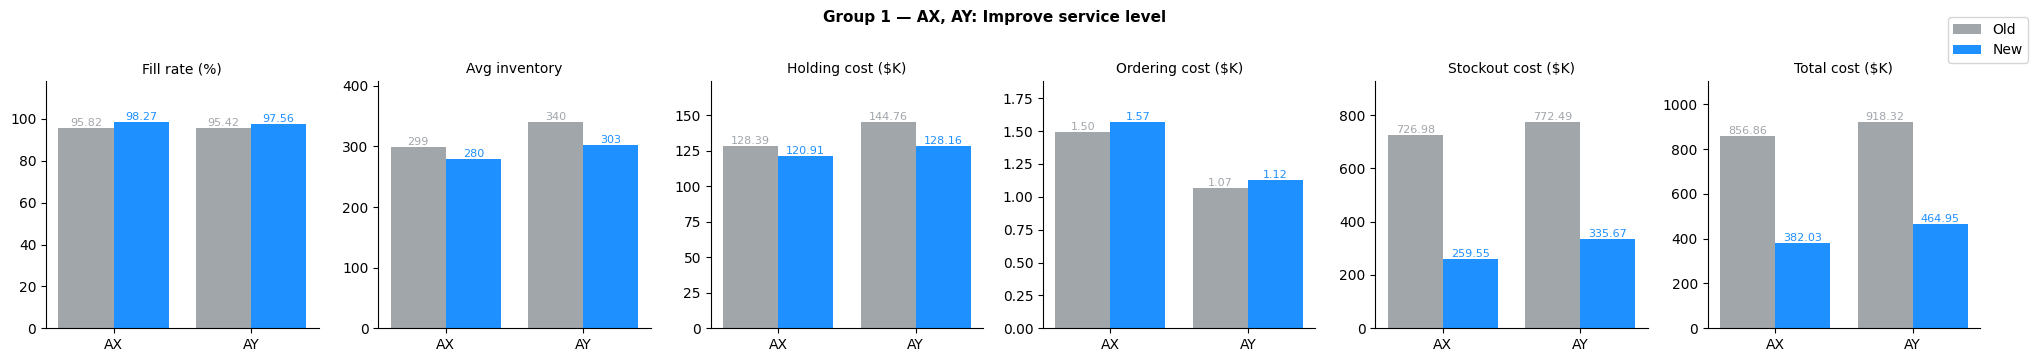

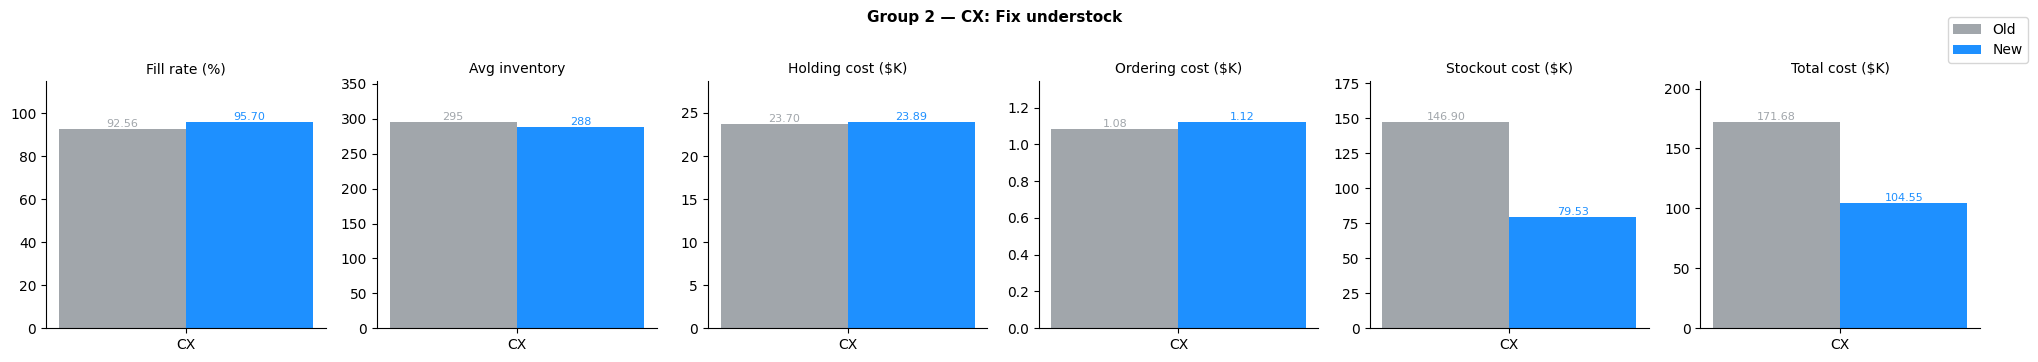

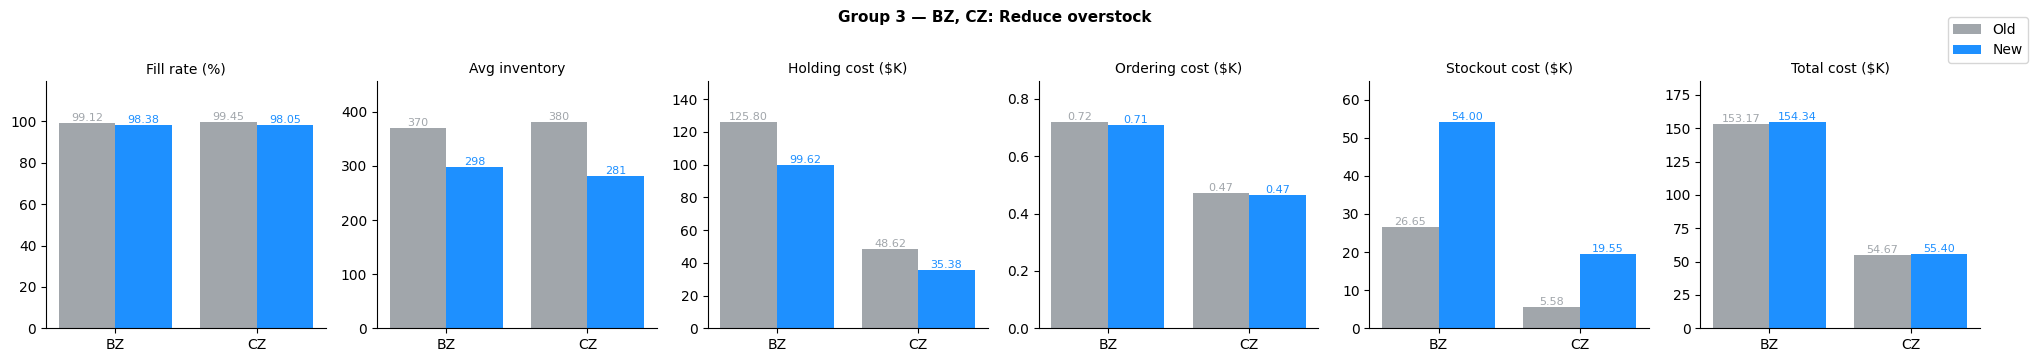

In [13]:
metrics = ['Fill rate (%)', 'Avg inventory', 'Holding cost ($K)', 'Ordering cost ($K)', 'Stockout cost ($K)', 'Total cost ($K)']
fmt     = ['.2f', '.0f', '.2f', '.2f', '.2f', '.2f']
scale   = [100, 1, 1, 1, 1, 1] # %fill rate

for group_name, skus in groups.items():
    fig, axes = plt.subplots(1, 6, figsize=(20, 3.5))
    fig.suptitle(group_name, fontsize=11, fontweight='bold', y=1.02)

    for j, (metric, f, s) in enumerate(zip(metrics, fmt, scale)):
        ax = axes[j]
        sku_names = list(skus.keys())
        old_vals = [skus[sk]['old'][j] * s for sk in sku_names]
        new_vals = [skus[sk]['new'][j] * s for sk in sku_names]
        x = np.arange(len(sku_names))

        bars_old = ax.bar(x - 0.2, old_vals, 0.4, label='Old', color='#A1A6AB')
        bars_new = ax.bar(x + 0.2, new_vals, 0.4, label='New', color='#1E90FF')

        for bar in bars_old:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{bar.get_height():{f}}', ha='center', va='bottom', fontsize=8, color='#A1A6AB')
        for bar in bars_new:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{bar.get_height():{f}}', ha='center', va='bottom', fontsize=8, color='#1E90FF')

        ax.set_title(metric, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(sku_names)
        ax.spines[['top', 'right']].set_visible(False)
        ax.set_ylim(0, max(old_vals + new_vals) * 1.2)

    fig.legend(['Old', 'New'], loc='upper right', bbox_to_anchor=(1.02, 1.02))
    plt.tight_layout()
    plt.show()

**Group 1 – AX, AY:**
- Fill rate increased **AX (+2.45%, 95.82% → 98.27%)**, **AY (+2.14%, 95.42% → 97.56%)**  
- Avg Inventory decreased **AX (-6.35%, 299 → 280)**, **AY (-10.9%, 340 → 303)**  
- Total Cost reduced sharply **AX (-55.42%)**, **AY (-49.37%)**  
- Stockout Cost dropped **AX (-64.3%, 726.98 → 259.55)**, **AY (-56.55%, 772.49 → 335.67)**  

**Insight:**  
**Best-performing group.** Achieves clear **Pareto improvement** — service ↑ while inventory, cost, and lost sales ↓ significantly.

**Group 2 – CX:**
- Fill rate increased **(+3.14%, 92.56% → 95.70%)**  
- Avg Inventory increased slightly **(-2.37%, 295 → 288)**  
- Total Cost decreased substantially **(-39.1%, 171.68 → 104.55)**
- Stockout Cost dropped sharply **(-45.86%, 146.90 → 79.53)**  

**Insight:**  
The policy successfully mitigates the understock problem while maintaining lean inventory levels. Service performance improves significantly, and the reduction in stockout costs more than offsets the small increase in operational costs, resulting in a substantial decrease in total cost.

**Group 3 – BZ, CZ:**
- Inventory reduced **BZ (-19.5%, 370 → 298)**, **CZ (-26.1%, 380 → 281)**  
- Fill rate slightly decreased **BZ (-0.7%, 99.12% → 98.38%)**, **CZ (-1.4%, 99.45% → 98.05%)**  
- Holding Cost reduced significantly  

**Insight:**  
Inventory is **efficiently reduced** with **minimal impact on service levels**. Although **stockout costs increase slightly**, they remain relatively small compared to the **savings in holding costs**. The results indicate a **controlled and economically justified trade-off**, moving the system toward a **more balanced cost–service position**.

## Key findings

**Overall Summary**
- **AX, AY & CX:** Strong optimization (**service ↑, cost ↓, lost sales ↓**)  
- **BZ, CZ:** Effective rebalancing (**inventory ↓**) with only minor service trade-off  

→ **New policy is well-optimized across all segments**, achieving a strong balance between cost and service level.

## Save data

In [14]:
policy_sku = policy_sku[['sku_id', 'class', 'lead_time', 'unit_cost', 'unit_price', 'order_quantity', 'target_service_level', 'new_safety_stock', 'new_rop']].rename(columns = {'new_safety_stock': 'safety_stock', 'new_rop': 'rop'})
old_policy_metric = old_policy[['sku_id', 'class', 'total_demand', 'total_sales', 'avg_inventory', 'fill_rate', 'turnover', 'DOI', 'stockout_cost', 'holding_cost', 'ordering_cost', 'total_cost']]
new_policy_metric = new_policy[['sku_id', 'class', 'total_demand', 'total_sales', 'avg_inventory', 'fill_rate', 'turnover', 'DOI', 'stockout_cost', 'holding_cost', 'ordering_cost', 'total_cost']]

In [15]:
policy_sku.to_csv(os.path.join(DATA_DIR, 'policy_sku.csv'), index=False)
old_policy_metric.to_csv(os.path.join(DATA_DIR, 'old_policy_metric.csv'), index=False)
new_policy_metric.to_csv(os.path.join(DATA_DIR, 'new_policy_metric.csv'), index=False)